# Baseline Auto-tuning Demo (v0.6.2+)

This notebook demonstrates the `autotune_baseline` / `apply_choice` workflow introduced in v0.6.2.
It covers both the **mapping** (`RamanMapping`) and **single-fit** (`RamanFit`) use cases using
fully synthetic data — no WDF files required.

### Workflow summary

1. Create a fit object with a placeholder baseline.
2. Call `autotune_baseline()` to score a grid of baseline candidates on a representative spectrum.
3. Inspect the RMSE ranking and select a winner.
4. Call `apply_choice(result.winner)` to commit the best baseline.
5. Run `fit_spectra()` / `fit_spectrum()` as normal.

**Prerequisites:** `pip install -e .` (base install — no extras required).

In [ ]:
import matplotlib
# matplotlib.use('Agg')  # headless backend for CI

import numpy as np
import matplotlib.pyplot as plt

from ramanpl.mapping import RamanMapping
from ramanpl.single_fit.RamanFit import RamanFit

print(f"RamanPL_2D version: {__import__('ramanpl').__version__}")

## 1. Synthetic data

A single Lorentzian peak at 400 cm⁻¹ on a sloped baseline, replicated into a 3×3 mapping cube.

In [2]:
rng = np.random.default_rng(42)

x = np.linspace(300.0, 500.0, 120)

def _lorentzian(x, center, fwhm, amplitude):
    gamma = fwhm / 2.0
    return amplitude * gamma**2 / ((x - center)**2 + gamma**2)

# Sloped background + Lorentzian peak + noise
background = 5.0 + 0.03 * (x - 300.0)
peak = _lorentzian(x, 400.0, 12.0, 120.0)
noise = rng.normal(0.0, 1.5, size=x.shape)
y_single = background + peak + noise

# 3x3 cube with small per-pixel variations
rows, cols = 3, 3
cube = np.stack(
    [y_single + rng.normal(0.0, 0.5, size=x.shape) for _ in range(rows * cols)],
    axis=0,
).reshape(rows, cols, len(x))

peak_bounds = {"A": ([388.0, 3.0, 0.01], [415.0, 25.0, 300.0])}

print(f"Spectral axis: {x[0]:.1f} – {x[-1]:.1f} cm⁻¹  ({len(x)} points)")
print(f"Cube shape: {cube.shape}")

Spectral axis: 300.0 – 500.0 cm⁻¹  (120 points)
Cube shape: (3, 3, 120)


## 2. RamanMapping — baseline auto-tuning

### 2a. Create the mapping object with a placeholder baseline

In [3]:
mapping = RamanMapping.from_arrays(
    cube, x, cols, rows,
    custom_peaks=peak_bounds,
    data_range=(300.0, 500.0),
    background_remove=True,
    baseline_method={"method": "poly", "poly_order": 1},
    smoothing=False,
)
print("Mapping created. Baseline method:", mapping.baseline_method)

Mapping created. Baseline method: {'method': 'poly', 'poly_order': 1}


### 2b. Score the baseline grid on seed pixel (1, 1)

`autotune_baseline` is **read-only** — it never modifies the object.

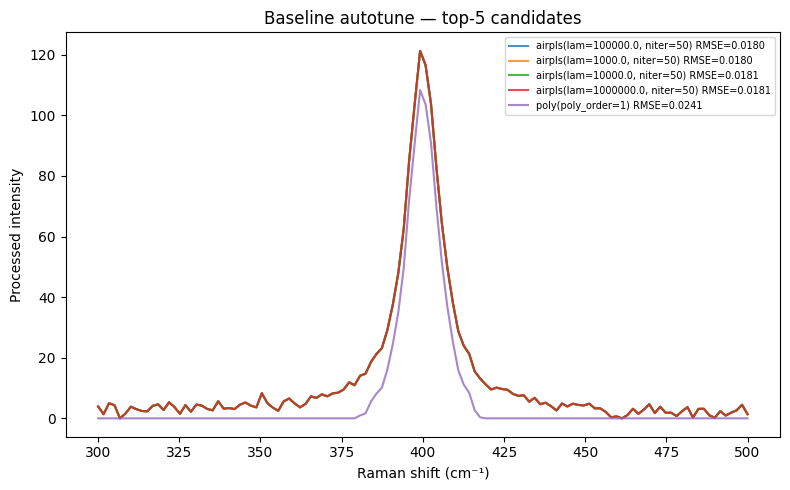

Candidates scored: 14
Seed pixel: (1, 1)

Top-5 ranking:
  # 1  method=airpls    kwargs={'lam': 100000.0, 'niter': 50}  RMSE=0.0180
  # 2  method=airpls    kwargs={'lam': 1000.0, 'niter': 50}  RMSE=0.0180
  # 3  method=airpls    kwargs={'lam': 10000.0, 'niter': 50}  RMSE=0.0181
  # 4  method=airpls    kwargs={'lam': 1000000.0, 'niter': 50}  RMSE=0.0181
  # 5  method=poly      kwargs={'poly_order': 1}  RMSE=0.0241

Winner: {'method': 'airpls', 'lam': 100000.0, 'niter': 50}


In [4]:
result = mapping.autotune_baseline(
    seed_coord=(1, 1),
    method_grids={
        "poly":     {"poly_order": [1, 2, 3, 4, 5]},
        "airpls":   {"lam": [1e3, 1e4, 1e5, 1e6], "niter": [50]},
        "gaussian": {"gaussian_sigma": [5, 10, 20, 50, 100]},
    },
    plot=True,
)

print(f"Candidates scored: {result.meta['n_candidates']}")
print(f"Seed pixel: {result.seed_coord}")
print()
print("Top-5 ranking:")
for rank, entry in enumerate(result.ranking[:5], start=1):
    print(f"  #{rank:2d}  method={entry['method']:8s}  kwargs={entry['kwargs']}  RMSE={entry['rmse']:.4f}")

print()
print("Winner:", result.winner)

### 2c. Verify object is unchanged after `autotune_baseline`

In [5]:
print("Baseline method after autotune (unchanged):", mapping.baseline_method)
assert mapping.baseline_method == {"method": "poly", "poly_order": 1}, "Object was mutated!"
print("OK — object not mutated by autotune_baseline")

Baseline method after autotune (unchanged): {'method': 'poly', 'poly_order': 1}
OK — object not mutated by autotune_baseline


### 2d. Commit the winner and run the full map fit

In [6]:
mapping.apply_choice(result.winner)
print("Baseline after apply_choice:", mapping.baseline_method)

mapping.fit_spectra(
    warm_start=True,
    fit_spectrum_kwargs=dict(
        adaptive_multistart=False,
        n_starts=1,
        diagnostics="light",
    ),
)
print("Fit complete.")

Baseline after apply_choice: {'method': 'airpls', 'lam': 100000.0, 'niter': 50}


Fitting (Raman mapping): 100%|██████████| 9/9 [00:00<00:00, 121.23it/s]

Successful fits: 9 / 9
Fit complete.


### 2e. Fit summary and feature table

In [7]:
rep = mapping.fit_summary()
print(rep)

df = mapping.feature_table()
print()
print("Feature table shape:", df.shape)
df.head()


=== Fit summary ===
Successful fits: 9 / 9 (100.0%)
RMSE (fit-space): mean: 0.01876 | median: 0.01848 | q50: 0.01848 | q90: 0.02251 | q95: 0.02269 | q99: 0.02283

Bound-sticking (params at bounds per successful pixel):
  - lower: mean 0, max 0
  - upper: mean 0, max 0
{'n_total': 9, 'n_ok': 9, 'n_fail': 0, 'success_rate': 1.0, 'rmse_stats': {'mean': 0.018755512980690472, 'median': 0.01847976444755466, 'q50': 0.01847976444755466, 'q90': 0.022514763439241466, 'q95': 0.022690462012230572, 'q99': 0.022831020870621856}, 'failure_reasons': {}, 'bounds': {'lower': {'mean': 0.0, 'max': 0}, 'upper': {'mean': 0.0, 'max': 0}}}

Feature table shape: (9, 10)


,x,y,A_position,A_fwhm,A_peak_height,A_peak_height_norm,rmse,ok,n_starts,n_params_at_bounds
0,0,0,400.010478,12.806052,120.121364,0.989853,0.016109,True,1,0
1,1,0,400.009906,12.731037,119.736616,0.988499,0.015257,True,1,0
2,2,0,399.973711,12.916178,120.138940,0.982395,0.018638,True,1,0
3,0,1,400.004603,13.048426,119.138029,0.982891,0.018480,True,1,0
4,1,1,399.969137,12.891100,119.639952,0.986746,0.018031,True,1,0


### 2f. Export — verify provenance block

After `apply_choice`, the TXT export includes a `baseline_autotune:` block.

In [8]:
import tempfile, os

with tempfile.NamedTemporaryFile(suffix=".txt", delete=False) as f:
    export_path = f.name

mapping.export_fit_map(export_path)

with open(export_path) as f:
    header_lines = [line for line in f if line.startswith("#")]

os.unlink(export_path)

autotune_lines = [l for l in header_lines if "baseline_autotune" in l or "winner" in l]
print("Provenance lines containing autotune info:")
for l in autotune_lines:
    print(" ", l.rstrip())

assert any("baseline_autotune" in l for l in header_lines), "baseline_autotune block missing from export!"
print()
print("OK — baseline_autotune provenance block present in export.")

Provenance lines containing autotune info:
  # baseline_autotune: {"methods": ["airpls", "poly", "gaussian"], "n_candidates": 14, "seed_coord": [1, 1], "winner": {"method": "airpls", "lam": 100000.0, "niter": 50}, "winner_rmse": 0.018031253838362037, "ranking_top5": [{"method": "airpls", "kwargs": {"lam": 100000.0, "niter": 50}, "rmse": 0.018031253838362037}, {"method": "airpls", "kwargs": {"lam": 1000.0, "niter": 50}, "rmse": 0.01804913042439364}, {"method": "airpls", "kwargs": {"lam": 10000.0, "niter": 50}, "rmse": 0.018073031999552812}, {"method": "airpls", "kwargs": {"lam": 1000000.0, "niter": 50}, "rmse": 0.01814283233825464}, {"method": "poly", "kwargs": {"poly_order": 1}, "rmse": 0.02405865755880338}]}

OK — baseline_autotune provenance block present in export.


## 3. RamanFit — baseline auto-tuning

The single-fit workflow is identical but operates on one spectrum.

### 3a. Create a RamanFit object

In [9]:
fit = RamanFit(
    spectra=y_single,
    wavenumber=x,
    custom_peaks=peak_bounds,
    background_remove=True,
    baseline_method={"method": "poly", "poly_order": 1},
    smoothing=False,
)
print("RamanFit created. Baseline method:", fit.baseline_method)

RamanFit created. Baseline method: {'method': 'poly', 'poly_order': 1}


### 3b. Score the baseline grid

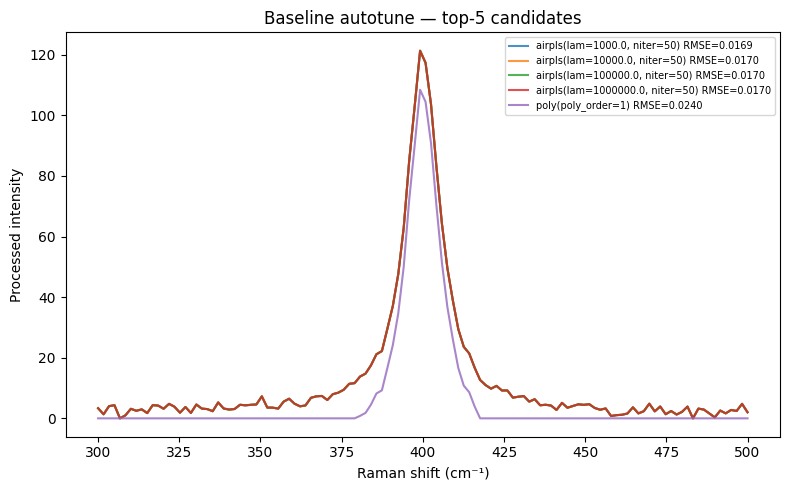

Candidates scored: 14

Top-5 ranking:
  # 1  method=airpls    kwargs={'lam': 1000.0, 'niter': 50}  RMSE=0.0169
  # 2  method=airpls    kwargs={'lam': 10000.0, 'niter': 50}  RMSE=0.0170
  # 3  method=airpls    kwargs={'lam': 100000.0, 'niter': 50}  RMSE=0.0170
  # 4  method=airpls    kwargs={'lam': 1000000.0, 'niter': 50}  RMSE=0.0170
  # 5  method=poly      kwargs={'poly_order': 1}  RMSE=0.0240

Winner: {'method': 'airpls', 'lam': 1000.0, 'niter': 50}


In [10]:
result_fit = fit.autotune_baseline(
    method_grids={
        "poly":     {"poly_order": [1, 2, 3, 4, 5]},
        "airpls":   {"lam": [1e3, 1e4, 1e5, 1e6], "niter": [50]},
        "gaussian": {"gaussian_sigma": [5, 10, 20, 50, 100]},
    },
    plot=True,
)

print(f"Candidates scored: {result_fit.meta['n_candidates']}")
print()
print("Top-5 ranking:")
for rank, entry in enumerate(result_fit.ranking[:5], start=1):
    print(f"  #{rank:2d}  method={entry['method']:8s}  kwargs={entry['kwargs']}  RMSE={entry['rmse']:.4f}")

print()
print("Winner:", result_fit.winner)

### 3c. Commit and fit

In [11]:
fit.apply_choice(result_fit.winner)
print("Baseline after apply_choice:", fit.baseline_method)

fit.fit_spectrum(n_starts=2)
diag = getattr(fit, "fit_diagnostics", {}) or {}
print("Fit complete. RMSE:", round(float(diag.get("rmse", float("nan"))), 4))

Baseline after apply_choice: {'method': 'airpls', 'lam': 1000.0, 'niter': 50}
Fit complete. RMSE: 0.0169


### 3d. Verify `apply_choice` refreshed derived attributes

In [12]:
assert fit.processed_spectra is not None, "processed_spectra not set"
assert fit.peak_intensity > 0, "peak_intensity not refreshed"
assert fit.intensity_normal is not None, "intensity_normal not set"
print("Peak intensity:", round(float(fit.peak_intensity), 3))
print("Wavenumber range: {:.1f} – {:.1f} cm⁻¹".format(fit.wavenumber[0], fit.wavenumber[-1]))
print("OK — derived attributes refreshed by apply_choice.")

Peak intensity: 121.301
Wavenumber range: 300.0 – 500.0 cm⁻¹
OK — derived attributes refreshed by apply_choice.


## 4. Summary

Both `RamanMapping` and `RamanFit` support the same two-step baseline auto-tuning pattern:

| Step | Call | Effect |
|------|------|--------|
| 1 | `autotune_baseline(...)` | Scores grid, returns ranked result — **object unchanged** |
| 2 | `apply_choice(result.winner)` | Commits winner, invalidates cache, re-applies pipeline |

After `apply_choice`, `fit_spectra()` / `fit_spectrum()` run with the updated baseline.
The export TXT header includes a `baseline_autotune:` provenance block documenting the winner.

## 5. Real-data example: non-linear background

The synthetic sections above use a clean linear background, which makes iterative methods
score identically (lam sensitivity is invisible). This section runs autotune on a real
2L-Graphene Raman spectrum that has a non-linear fluorescent background.

Data: `example-usage/Ramanfit/Raman Sample 532nm 2L-Graphene.txt` (532 nm excitation,
bilayer graphene on substrate).

In [13]:
from ramanpl import RamanFit

# Load real 2L-Graphene spectrum
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='../Ramanfit/Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900),
)

# Construct RamanFit with a polynomial placeholder baseline
fit_real = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method={"method": "poly", "poly_order": 4},
    smoothing=True,
    smooth_order=8,
)

# Update bounds for the 2D sub-peaks of bilayer graphene
fit_real.update_bounds(
    **{
        '2D-1B': ([2600, 0, 0], [2620, 10, 10]),
        '2D-1A': ([2620, 0, 0], [2650, 10, 20]),
        '2D-2A': ([2650, 0, 0], [2700, 10, 20]),
        '2D-2B': ([2700, 0, 0], [2720, 10, 10]),
    }
)
fit_real.remove_peaks('D')   # D peak not expected for this sample

print(f"Loaded spectrum: {len(wavenumber)} points, "
      f"{wavenumber[0]:.0f}–{wavenumber[-1]:.0f} cm⁻¹")

Loaded spectrum: 1008 points, 2827–1300 cm⁻¹


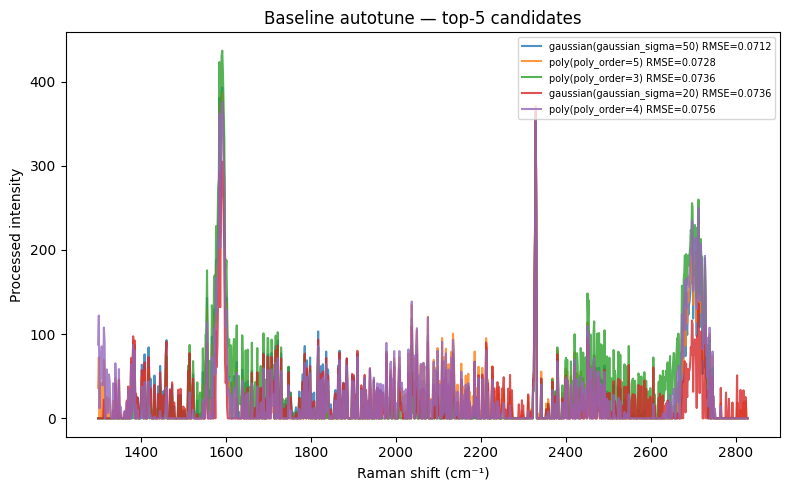

In [14]:
# Score the full 24-candidate default grid on the real spectrum
result_real = fit_real.autotune_baseline(plot=True)

In [15]:
print(f"Candidates scored: {result_real.meta['n_candidates']}")
print()
print("Top-5 ranking:")
for rank, entry in enumerate(result_real.ranking[:5], start=1):
    print(f"  #{rank:2d}  method={entry['method']:8s}  kwargs={entry['kwargs']}  RMSE={entry['rmse']:.4f}")

Candidates scored: 24

Top-5 ranking:
  # 1  method=gaussian  kwargs={'gaussian_sigma': 50}  RMSE=0.0712
  # 2  method=poly      kwargs={'poly_order': 5}  RMSE=0.0728
  # 3  method=poly      kwargs={'poly_order': 3}  RMSE=0.0736
  # 4  method=gaussian  kwargs={'gaussian_sigma': 20}  RMSE=0.0736
  # 5  method=poly      kwargs={'poly_order': 4}  RMSE=0.0756


Committed baseline: {'method': 'gaussian', 'gaussian_sigma': 50}
Fit complete.


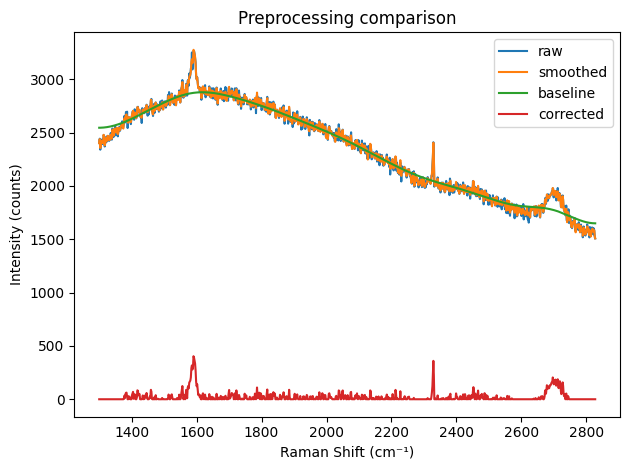


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.51         13.64         376.62         6.82      
2D-1B                2600.00         20.00         0.00           10.00     
2D-1A                2620.00         20.00         0.00           10.00     
2D-2A                2694.05         20.00         163.60         10.00     
2D-2B                2714.60         19.86         129.37         9.93      

Normalized Residual: 0.3021 (0 = perfect fit)


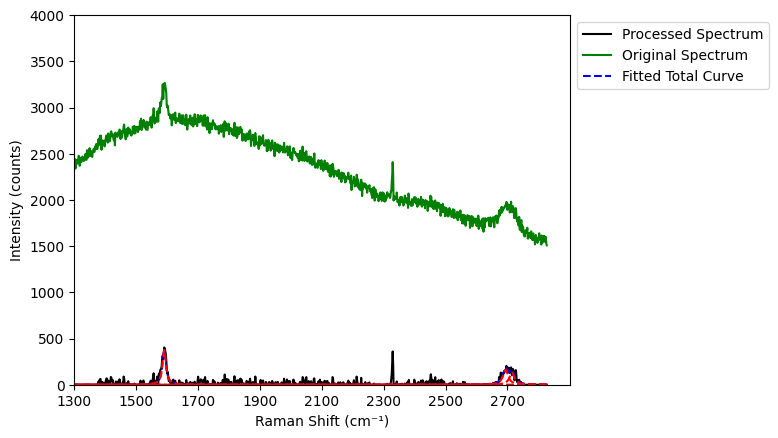

In [16]:
fit_real.apply_choice(result_real.winner)
print("Committed baseline:", fit_real.baseline_method)

params_real, _ = fit_real.fit_spectrum()
print("Fit complete.")

fit_real.plot_fit(params_real, offset=0, scale=1,
                  x_lim=1300, y_lim=[0, 4000],
                  x_ticks=range(1300, 2800, 200))

### Observations

**Winner: Gaussian (σ = 50), RMSE = 0.0712** — neither iterative (asls/arpls/airpls) nor
polynomial took first place. The top-5 is split between `gaussian` (σ ∈ {20, 50}) and `poly`
(orders 3, 4, 5); all iterative methods fell outside it entirely.

**Why iterative methods underperformed here:** The bilayer-graphene spectrum spans
1300–2900 cm⁻¹, and the Raman peaks (G ~ 1580 cm⁻¹, 2D complex ~ 2620–2720 cm⁻¹) occupy
a substantial fraction of that window. Iterative reweighting (asls/arpls/airpls) assigns low
weights to high-intensity points, but when peaks are broad and intense they bleed into
neighbouring points and the algorithm ends up tracking down toward the peak shoulder rather
than the true background level. Small lam values amplify this: the baseline becomes too
flexible and follows the spectral envelope too closely (over-correction, baseline dips below
peak feet). Large lam values overcorrect in the opposite sense: the curve is too stiff to
follow the fluorescent hump, leaving residual curvature in the corrected spectrum (under-correction).

**Why Gaussian won — and the "cuts the data" trade-off:** The Gaussian baseline is a heavily
smoothed copy of the raw spectrum. With σ = 50 points the smoothing window spans both peak
regions, so the estimated baseline already contains a fraction of the peak signal. After
subtraction the corrected spectrum is lower (peaks appear to be "cut") compared with, say,
a poly-4 correction. The autotune metric is post-fit RMSE, not visual height: if the Gaussian
baseline leaves a flatter residual after fitting, it wins on RMSE even if the absolute peak
amplitude is depressed. This is expected behaviour — it is worth inspecting `plot_fit` to
confirm that peak positions and widths are physically reasonable before accepting this winner.
If the suppressed amplitude is undesirable, `poly` order 5 (RMSE = 0.0728, only ~2% worse)
is a conservative alternative that preserves more peak area.

Unlike the synthetic example where all iterative methods scored similarly (flat background →
lam insensitive), the real spectrum shows clear separation between methods because the
fluorescent background has curvature that each algorithm tracks differently.